In [20]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
df_final = pd.read_csv("cafba_sweep_results.csv", index_col=0)

In [22]:
df_final

,w_c,growth_rate,phi_C,phi_E,phi_R,flux_PFK,flux_EDD,flux_glc
0,0.000000,0.604509,0.000000,0.381838,0.168767,2.669513,0.000000,9.188102
1,0.000102,0.603341,0.000936,0.381100,0.168568,2.664352,0.000000,9.170340
2,0.000210,0.602107,0.001924,0.380320,0.168358,2.658903,0.000000,9.151587
3,0.000331,0.600739,0.003018,0.379457,0.168126,2.652864,0.000000,9.130801
4,0.000469,0.599171,0.004274,0.378466,0.167859,2.645938,0.000000,9.106961
...,...,...,...,...,...,...,...,...
95,0.884379,0.061084,0.429927,0.043755,0.076384,0.428548,0.008368,0.486134
96,0.912397,0.059412,0.431407,0.042558,0.076100,0.416818,0.008139,0.472828
97,0.941002,0.057797,0.432836,0.041401,0.075826,0.405487,0.007918,0.459974
98,0.970201,0.056237,0.434218,0.040283,0.075560,0.394539,0.007704,0.447554


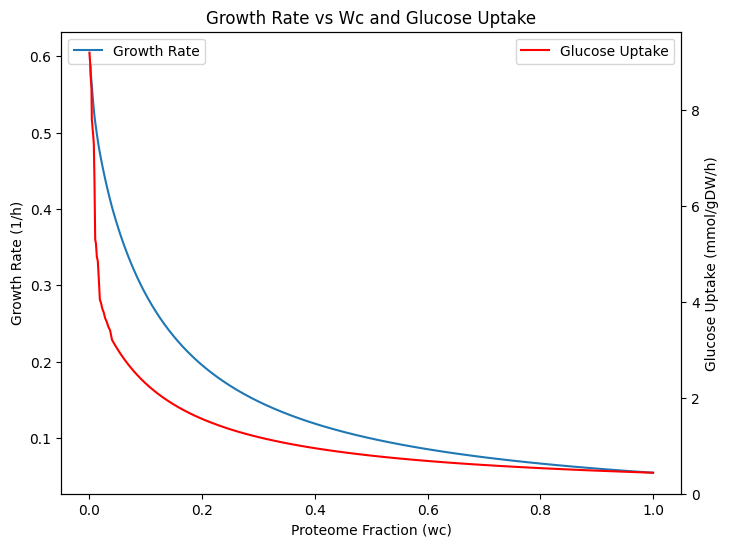

In [23]:
# Plot wc versus growth rate and the glucose uptake flux on the same graph with two y axis (growth rate on left, glucose uptake on right)
plt.figure(figsize=(8, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(df_final['w_c'], df_final['growth_rate'], label='Growth Rate')
ax2.plot(df_final['w_c'], df_final['flux_glc'], label='Glucose Uptake', color='red')

ax1.set_xlabel('Proteome Fraction (wc)')
ax1.set_ylabel('Growth Rate (1/h)')
ax2.set_ylabel('Glucose Uptake (mmol/gDW/h)')

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Growth Rate vs Wc and Glucose Uptake')

# Save the plot
plt.savefig("cafba_wc_growth_rate.png", dpi=300)
plt.show()

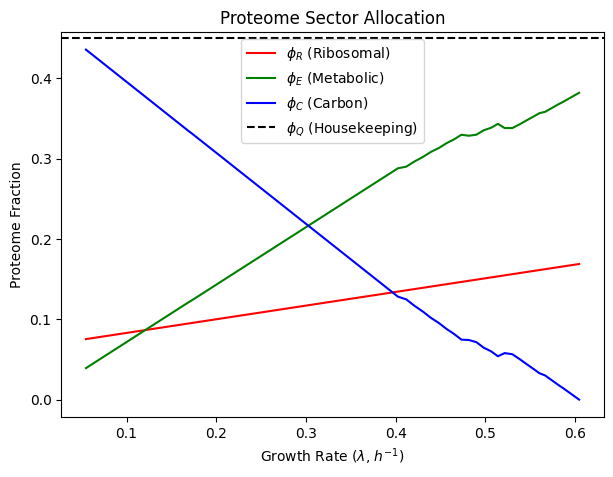

In [24]:
plt.figure(figsize=(7, 5))
plt.plot(df_final['growth_rate'], df_final['phi_R'], color='red', label='$\phi_R$ (Ribosomal)')
plt.plot(df_final['growth_rate'], df_final['phi_E'], color='green', label='$\phi_E$ (Metabolic)')
plt.plot(df_final['growth_rate'], df_final['phi_C'], color='blue', label='$\phi_C$ (Carbon)')
plt.axhline(y=PHI_Q, color='black', linestyle='--', label='$\phi_Q$ (Housekeeping)')
plt.xlabel('Growth Rate ($\lambda$, $h^{-1}$)')
plt.ylabel('Proteome Fraction')
plt.legend()
plt.title('Proteome Sector Allocation')

# Save the plot
plt.savefig("cafba_proteome_allocation.png", dpi=300)
plt.show()

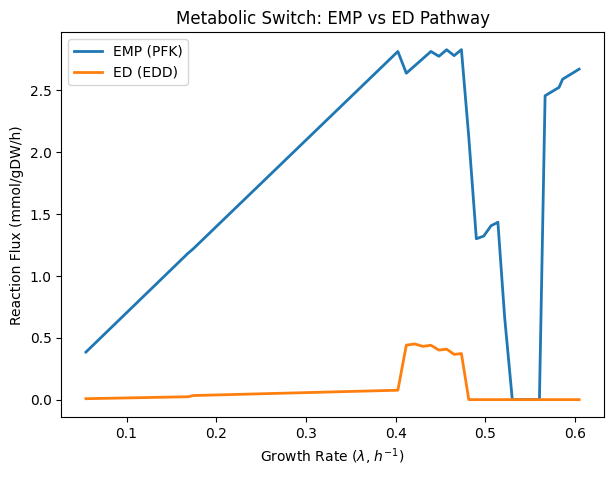

In [25]:
plt.figure(figsize=(7, 5))
plt.plot(df_final['growth_rate'], df_final['flux_PFK'], label='EMP (PFK)', linewidth=2)
plt.plot(df_final['growth_rate'], df_final['flux_EDD'], label='ED (EDD)', linewidth=2)
plt.xlabel('Growth Rate ($\lambda$, $h^{-1}$)')
plt.ylabel('Reaction Flux (mmol/gDW/h)')
plt.title('Metabolic Switch: EMP vs ED Pathway')
plt.legend()

# Save the plot
plt.savefig("cafba_emp_ed_fluxes.png", dpi=300)
plt.show()